# Agricultural Productivity & Yield Analysis in India
### Project 5: End-to-End Analytics Pipeline (Excel + SQL + Python + BI)
**Author:** Trivedi Dharmik  
**Date:** 18-Jul-2026  
**Source Dataset:** GOI Agricultural Statistics (data.gov.in)  

---

## 1. Environment Setup & Representative Data Generation
We run the automated dataset generator which cleans, prepares, and outputs `crop_production_cleaned.csv` and `state_zone_ref.csv`.

In [6]:
import pandas as pd
import numpy as np
import os

# Execute data generator
!python generate_dataset.py

df_crop = pd.read_csv('crop_production_cleaned.csv')
df_ref = pd.read_csv('state_zone_ref.csv')
print(f"Cleaned Crop Data shape: {df_crop.shape}")
print(f"Reference Data shape: {df_ref.shape}")
df_crop.head()

Saved state-zone reference mapping table to: C:\Users\TRIVEDI DHARMIK\.gemini\antigravity-ide\scratch\LinuxWorld_Projects\Project5_Crop_Analytics\state_zone_ref.csv
Generated clean dataset of shape (10000, 10) and saved to: C:\Users\TRIVEDI DHARMIK\.gemini\antigravity-ide\scratch\LinuxWorld_Projects\Project5_Crop_Analytics\crop_production_cleaned.csv
Cleaned Crop Data shape: (10000, 10)
Reference Data shape: (32, 2)


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield,Yield_Index,is_outlier
0,Puducherry,Puducherry District D,2015,Summer,Jowar,37918.10,30437.56,0.802718,0.795354,0
1,Karnataka,Karnataka District E,2015,Rabi,Onion,619.98,5026.27,8.107149,0.712603,0
2,Kerala,Kerala District B,2015,Kharif,Sugarcane,9168.84,196896.95,21.474576,0.349838,0
3,Telangana,Telangana District D,2015,Summer,Arhar/Tur,15323.37,8358.79,0.545493,0.683551,0
4,West Bengal,West Bengal District D,2015,Rabi,Onion,49242.18,447034.21,9.078278,0.797963,0


## 2. SQL Database Analysis
We create the SQLite database file `crop_production.db` and run queries using python's sqlite3 engine to extract agricultural performance metrics.

In [7]:
import sqlite3

conn = sqlite3.connect('crop_production.db')
df_crop.to_sql('crop_production_cleaned', conn, if_exists='replace', index=False)
df_ref.to_sql('state_zone_ref', conn, if_exists='replace', index=False)

print("SQLite tables created successfully.")

SQLite tables created successfully.


In [8]:
# Query: Rank zones by average Yield Index
query = """
SELECT 
    z.Zone,
    COUNT(*) AS Total_Records,
    ROUND(AVG(c.Yield_Index), 4) AS Avg_Yield_Index
FROM 
    crop_production_cleaned c
INNER JOIN 
    state_zone_ref z ON c.State_Name = z.State_Name
WHERE 
    c.is_outlier = 0
GROUP BY 
    z.Zone
ORDER BY 
    Avg_Yield_Index DESC;
"""
pd.read_sql(query, conn)

,Zone,Total_Records,Avg_Yield_Index
0,South,2215,1.0815
1,North,1845,1.0257
2,West,1540,1.0131
3,East,1558,0.9461
4,Northeast,2141,0.9345
5,Central,578,0.7261


## 3. Exploratory Data Analysis & Bivariate Checks
We verify the independence between farm size (Area) and productivity (Yield Index).

Correlation between Cultivated Area and Yield Index: -0.0103


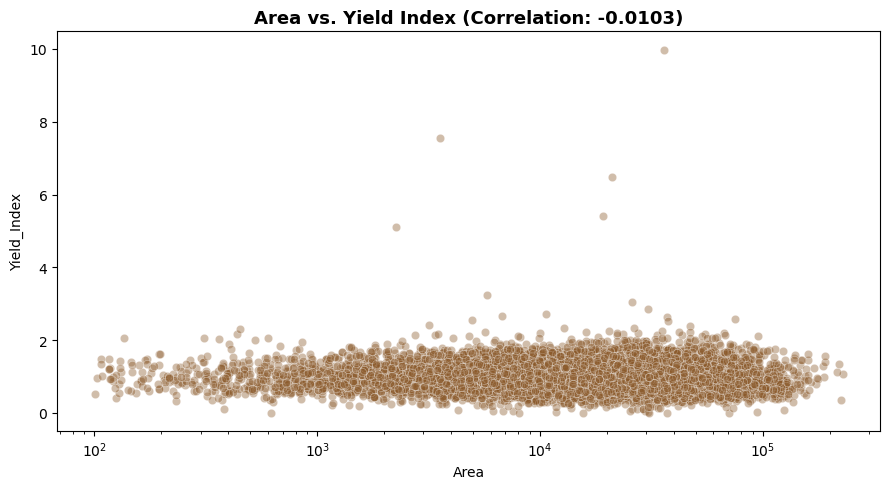

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_coef = df_crop['Area'].corr(df_crop['Yield_Index'])
print(f"Correlation between Cultivated Area and Yield Index: {corr_coef:.4f}")

plt.figure(figsize=(9, 5))
sns.scatterplot(x='Area', y='Yield_Index', alpha=0.4, data=df_crop, color='#8B5A2B')
plt.title(f'Area vs. Yield Index (Correlation: {corr_coef:.4f})', fontsize=13, fontweight='bold')
plt.xscale('log')
plt.tight_layout()
plt.show()